In [1]:
from abracalibra.forward_model import ForwardModel
from abracalibra.approximatebayesiancomputation import ApproximateBayesianComputation
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask
from abracalibra.summary import implausibility_univariate_distr
from torch.distributions import MultivariateNormal,Uniform


import torch
import matplotlib.pyplot as plt 

def sine_wave(x, a, b, c,d):
    return a * torch.sin(b * x + c)*torch.exp(-x/3)  + d

x = torch.linspace(0, 5, 10)
fixed_params = {'a': 1.0, 'c': 0.4,'d':0.3}
noise = 0.05

y = sine_wave(x, **fixed_params, b=0.78) + torch.randn_like(x)*noise

fwd = ForwardModel(sine_wave,vectorized=True, x=x, a=fixed_params['a'], c=fixed_params['c'], d=fixed_params['d'])

observables = MultivariateNormal(y, noise*noise*torch.eye(len(y)))

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
priors = {'b':Uniform(0,2)}
def summary(y,true_y):
    return torch.max(implausibility_univariate_distr(y,true_y),dim=-1).values 
hm = HistoryMatchingMultiTask(['b'],priors,observables,summary,ensemble_size=10,implausibility_cutoff=3,forward=fwd)
hm.calibrate(3)

Step 0 Loss: 1.013902187347412
Step 1 Loss: 0.9892600774765015
Step 2 Loss: 0.9649679660797119
Step 3 Loss: 0.9410592913627625
Step 4 Loss: 0.9175633192062378
Step 5 Loss: 0.8945106267929077
Step 6 Loss: 0.8719226121902466
Step 7 Loss: 0.849793553352356
Step 8 Loss: 0.828083336353302
Step 9 Loss: 0.8067283630371094
Step 10 Loss: 0.7856442332267761
Step 11 Loss: 0.7647265791893005
Step 12 Loss: 0.7438667416572571
Step 13 Loss: 0.722981333732605
Step 14 Loss: 0.7020295858383179
Step 15 Loss: 0.6810148358345032
Step 16 Loss: 0.6599811315536499
Step 17 Loss: 0.6390024423599243
Step 18 Loss: 0.6181647777557373
Step 19 Loss: 0.5975270867347717
Step 20 Loss: 0.5770815014839172
Step 21 Loss: 0.5567647814750671
Step 22 Loss: 0.5365244746208191
Step 23 Loss: 0.5163499712944031
Step 24 Loss: 0.4962513744831085
Step 25 Loss: 0.4762285649776459
Step 26 Loss: 0.4562453329563141
Step 27 Loss: 0.43623828887939453
Step 28 Loss: 0.41616126894950867
Step 29 Loss: 0.396022766828537
Step 30 Loss: 0.3758703

In [3]:
nroy_volume = [hm.estimate_nroy_volume(i)/hm.estimate_nroy_volume(0) for i in range(3)]

In [4]:
nroy_volume

[tensor(1.), tensor(0.0808), tensor(0.0808)]

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_75015/2443455306.py:17: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel("$\omega$")
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_75015/2443455306.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel("$\omega$")


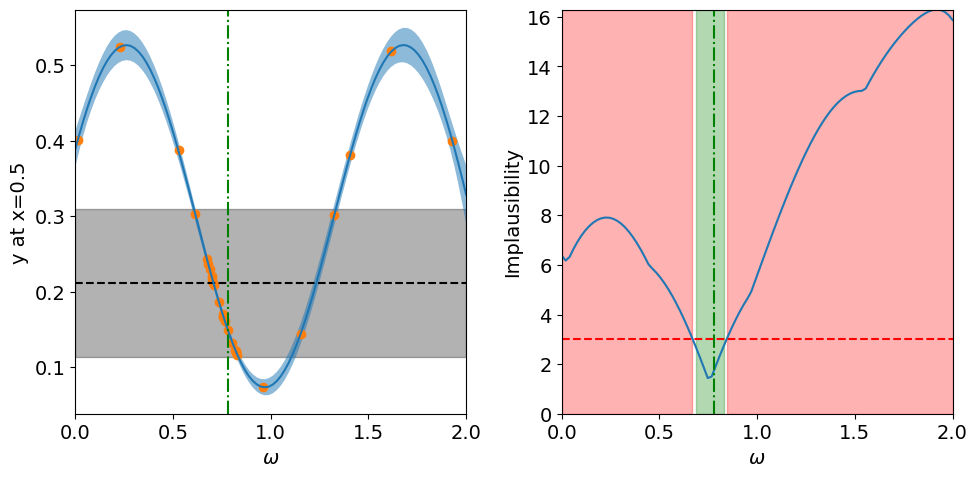

In [5]:
em = hm.emulators[hm.current_wave - 1]
em.eval()
plt.rcParams.update({'font.size': 14})
a = torch.linspace(0, 2, 100)
imp = hm.implausibility(a,wave=hm.current_wave - 1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
plot_dim = 8
with torch.no_grad():
    pred_val = em(a)
    lower,upper = pred_val.confidence_region()
    ax1.axhline(y=y[plot_dim],color='black',linestyle='--')
    ax1.fill_between(a,y[plot_dim] - 1.96*noise,y[plot_dim] + 1.96*noise,alpha=0.3,color='black')
    ax1.set_xlim(0,2)
    ax1.plot(a,pred_val.mean[:,plot_dim])
    ax1.fill_between(a,lower[:,plot_dim],upper[:,plot_dim],alpha=0.5)
    ax1.scatter(hm.params[:,:].view(-1,1),hm.results[:,:,plot_dim].view(-1,1))
    ax1.set_xlabel("$\omega$")
    ax1.axvline(0.78,color='green',linestyle='-.')
    ax1.set_ylabel("y at x=0.5")

    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='green',where=imp<3)
    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='red',where=imp>=3)
    ax2.plot(a,imp)
    ax2.set_xlim(0,2)
    ax2.set_ylim(0,imp.max())
    ax2.axvline(0.78,color='green',linestyle='-.')
    ax2.axhline(3,color='red',linestyle='--')
    ax2.set_xlabel("$\omega$")
    ax2.set_ylabel("Implausibility")

fig.tight_layout()
fig.savefig("history_matching.png",dpi=300)



In [6]:
def harder_sine_wave(x,y,a,b,c,d,e):
    return a * torch.sin(b * x + c*y + d)  + e

x = torch.linspace(0, 5,5)
y = torch.linspace(0,5,5)
X,Y = torch.meshgrid(x,y,indexing='ij')

fixed_params = {
    'a': 1.0,
    'b': 0.78,
    'c': 0.4,
    'd': 0.3,
    'e': 0.5
}

noise = 0.05    
fwd = ForwardModel(harder_sine_wave,vectorized=True, x=X.ravel(), y=Y.ravel())
out = fwd(torch.tensor([fixed_params['a'],fixed_params['b'],fixed_params['c'],fixed_params['d'],fixed_params['e']]))
observables = MultivariateNormal(out, noise*noise*torch.eye(X.numel()))


In [ ]:
from abracalibra.history_matching import HistoryMatchingSingleTaskGP

ENS = 50
parameters = ['a','b','c','d','e']
priors = {'a':Uniform(0,2.0),'b':Uniform(0,1),'c':Uniform(0,1),'d':Uniform(0,1),'e':Uniform(0,1)}
def summary(y,true_y):
    dist = torch.abs(y.mean - true_y.mean.unsqueeze(-1))
    var = y.variance + true_y.variance.unsqueeze(-1)
    imp = dist/torch.sqrt(var)
    return torch.max(imp,dim=0).values 
hm = HistoryMatchingSingleTaskGP(parameters,priors,observables,summary,ensemble_size=ENS,implausibility_cutoff=3,forward=fwd)
truth = torch.tensor(list(fixed_params.values()))
hm.calibrate(3,verbose=True,sanity_check=truth)

Working on wave 0


/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/botorch/models/utils/assorted.py:265: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/botorch/models/utils/assorted.py:268: InputDataWarning: Data (outcome observations) is not standardized (std = tensor([0.4615, 0.5587, 0.5439, 0.7707, 0.9914, 0.5641, 0.5704, 0.7710, 0.9605,
        0.9994, 0.5483, 0.7706, 0.9053, 0.8879, 0.9277, 0.7438, 0.8839, 0.8192,
        0.8331, 0.8678, 0.8795, 0.8527, 0.8597, 0.8567, 0.8882],
       dtype=torch.float64), mean = tensor([0.9887, 1.3370, 1.2289, 0.8259, 0.4840, 1.3057, 1.3072, 0.9633, 0.5814,
        0.4266, 1.2141, 0.9779, 0.6416, 0.4455, 0.4520, 0.8617, 0.6329, 0.4717,
        0.4368, 0.4596, 0.5597, 0.4887, 0.4697, 0.4477, 0.3822],
       dtype=torch.float64)).Please consider scaling the input to zero mean and unit vari

In [ ]:
import joblib

joblib.dump(hm,f"history_matching_linear_model_N{ENS}.pkl")

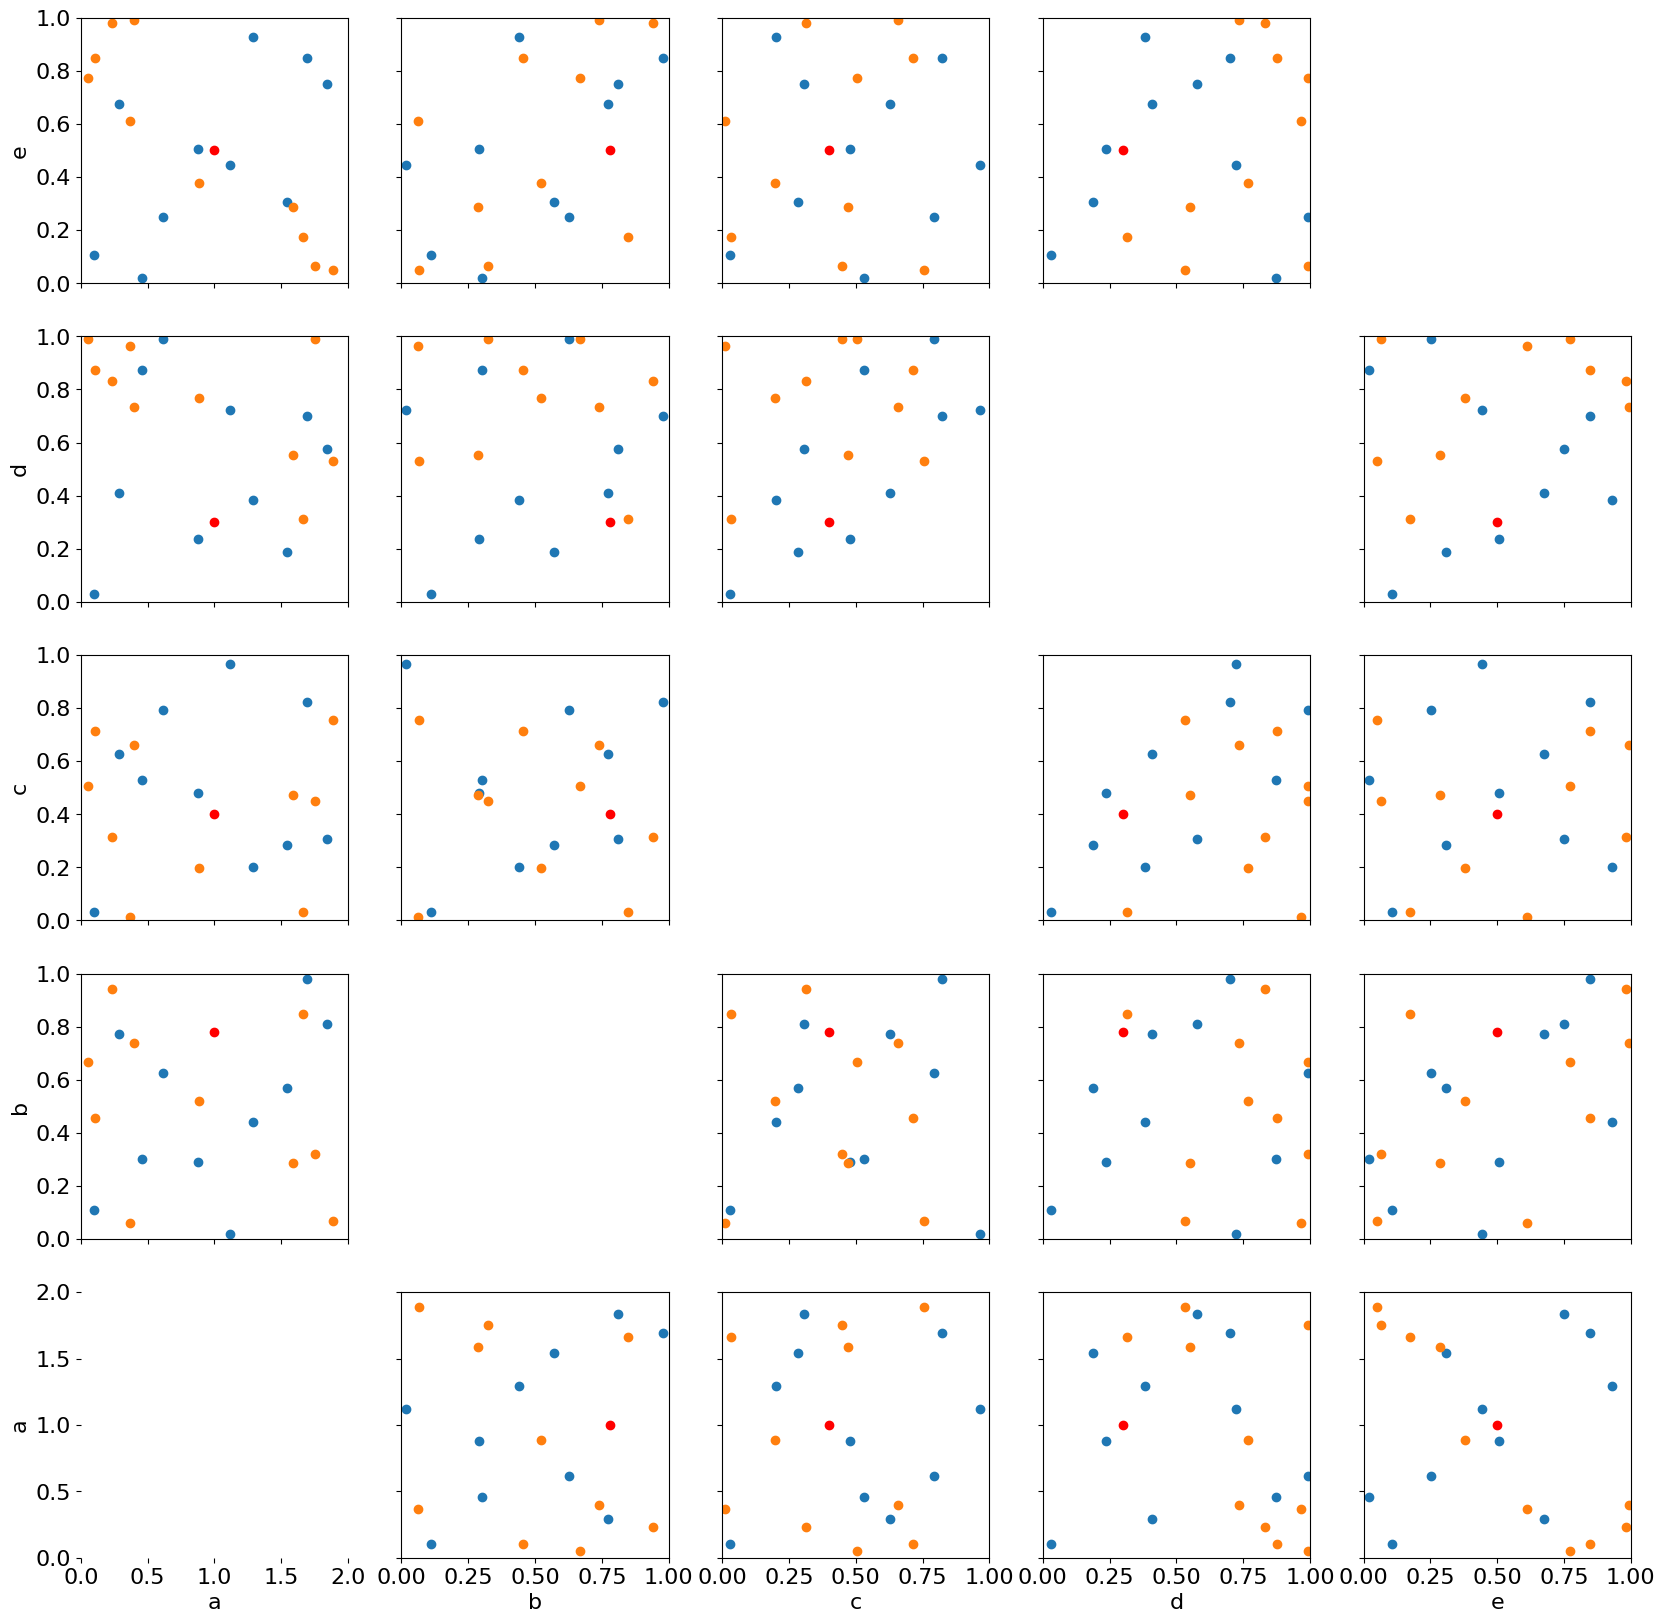

In [59]:

plt.rcParams.update({'font.size': 16})
fig, axs = plt.subplots(5,5,figsize=(20,20),sharex='col',sharey='row')
key_list = list(fixed_params.keys())
with torch.no_grad():
    for row in range(5):
        actual_row = 4 - row
        for col in range(5):
            if actual_row == col:
                # turn axis off
                            # ax[i][j].xaxis.set_visible(False)
                if actual_row == 0 and col == 0:
                    axs[row][col].set_ylabel(key_list[actual_row])
                    axs[row][col].set_xlabel(key_list[col]) 
                    axs[row][col].tick_params(top=False,right=False)   
                else:    
                    axs[row][col].tick_params(left=False,bottom=False,right=False,top=False)    
                # ax[i][j].yaxis.set_visible(False)
                plt.setp(axs[row][col].spines.values(), visible=False)   
                continue
            else:
                for i in range(2):
                    params = hm.params[i]
                    axs[row][col].scatter(params[:,col],params[:,actual_row])
                axs[row][col].scatter(fixed_params[key_list[col]],fixed_params[key_list[actual_row]],color='red')
                axs[row][col].set_xlim(hm.prior_list[col].support.lower_bound,hm.prior_list[col].support.upper_bound)
                axs[row][col].set_ylim(hm.prior_list[actual_row].support.lower_bound,hm.prior_list[actual_row].support.upper_bound)
            if col == 0:
                axs[row][col].set_ylabel(key_list[actual_row])
            if row == 4:  
                axs[row][col].set_xlabel(key_list[col])    
fig.savefig("history_matching_sine_5params_ENS.png")

### EKI 

In [80]:
from abracalibra.eki import EnsembleKalmanInversion
ENS = 50
eki = EnsembleKalmanInversion(parameters,priors,observables,ensemble_size=ENS,forward=fwd)
best_params = eki.calibrate(5)

In [81]:
eki_params = eki.parameters

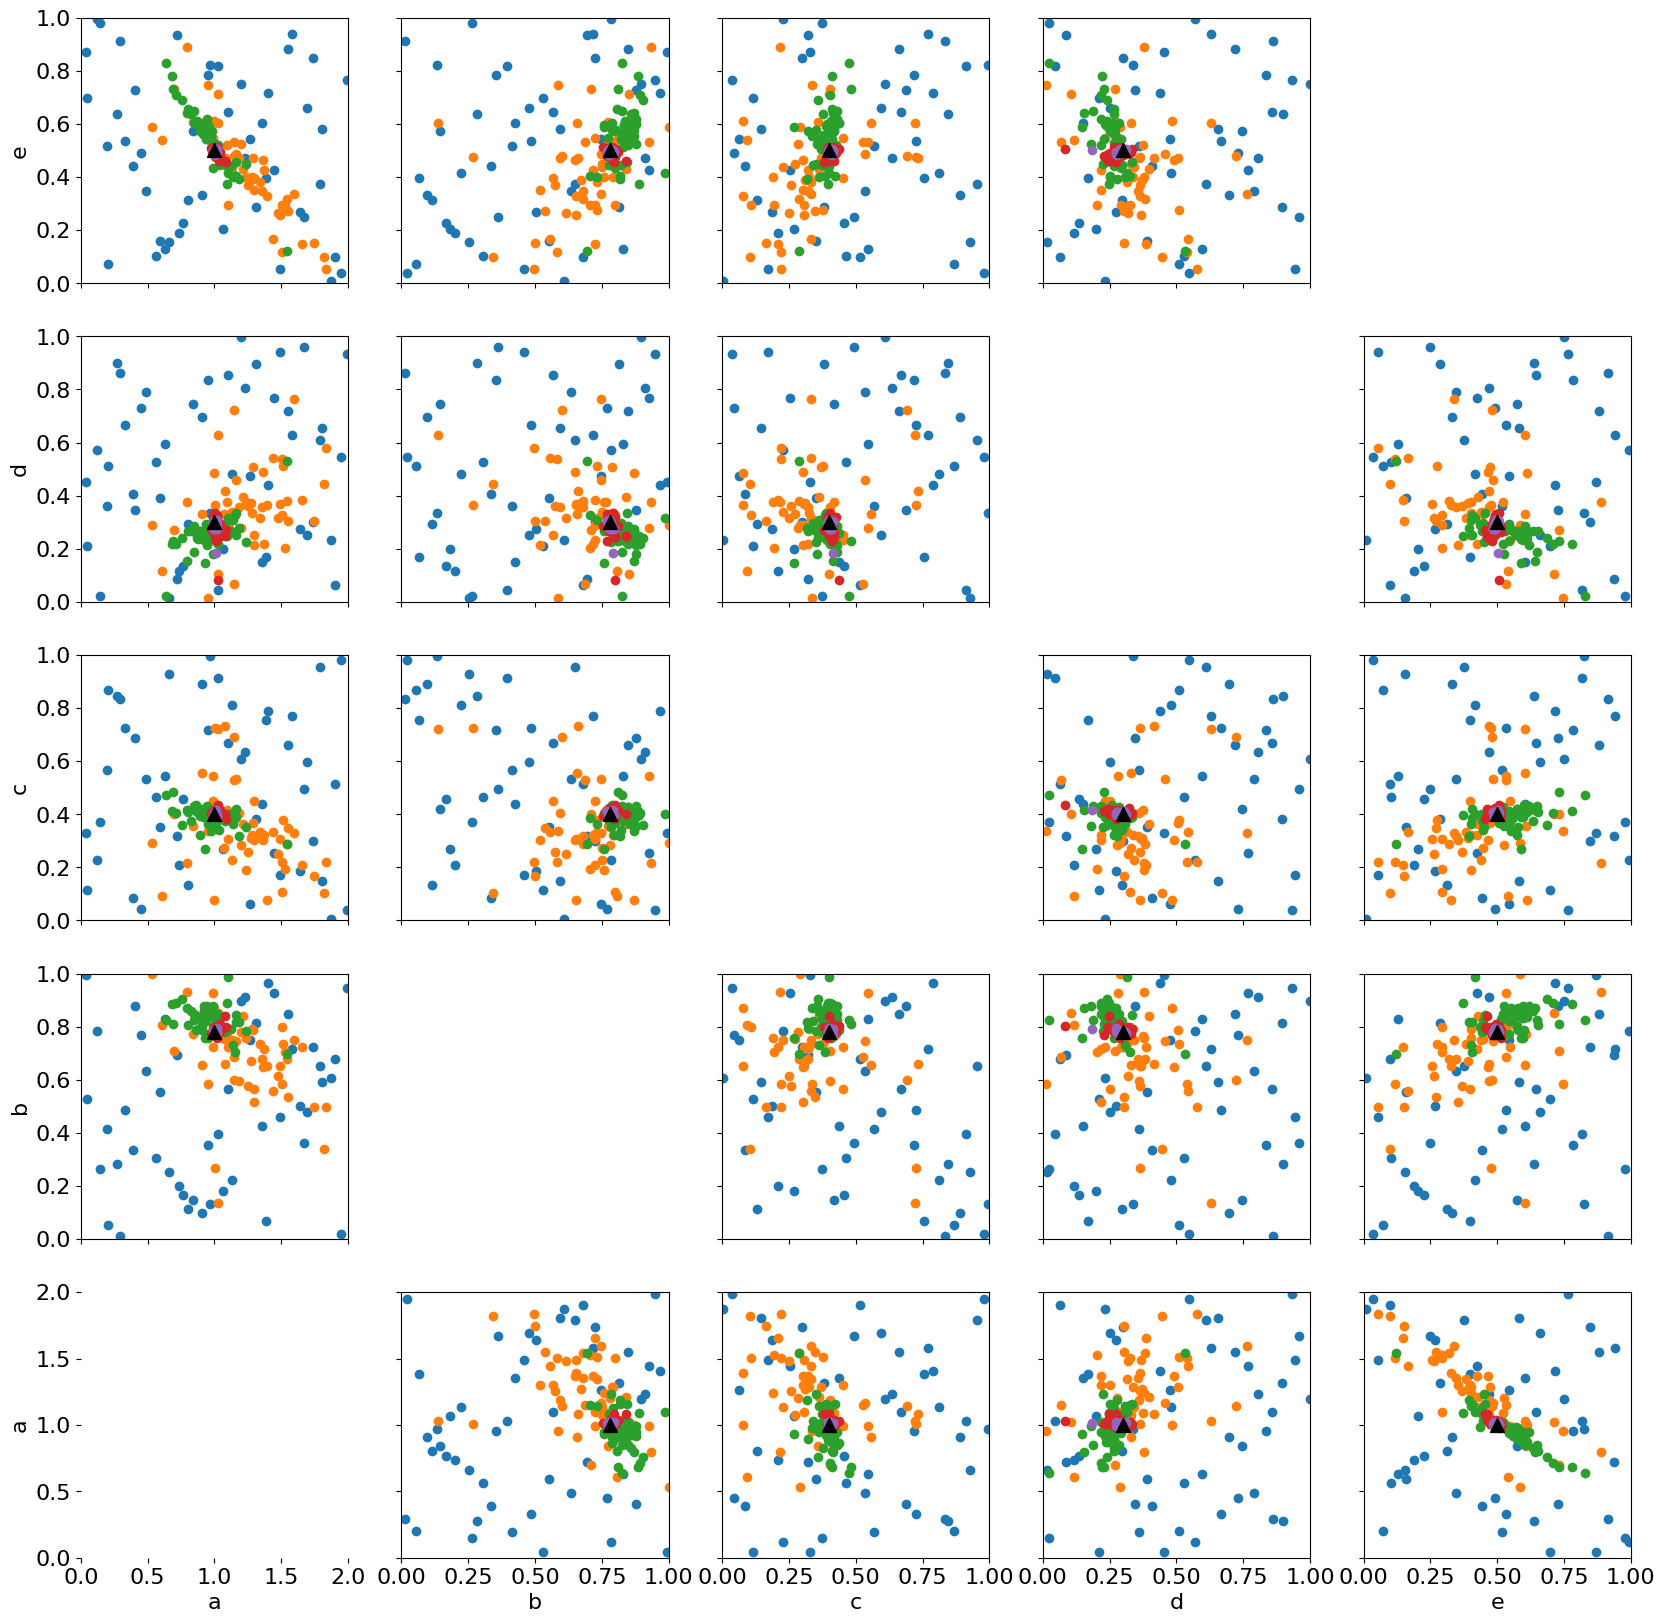

In [82]:
plt.rcParams.update({'font.size': 16})
fig, axs = plt.subplots(5,5,figsize=(20,20),sharex='col',sharey='row')
key_list = list(fixed_params.keys())
with torch.no_grad():
    for row in range(5):
        actual_row = 4 - row
        for col in range(5):
            if actual_row == col:
                # turn axis off
                            # ax[i][j].xaxis.set_visible(False)
                if actual_row == 0 and col == 0:
                    axs[row][col].set_ylabel(key_list[actual_row])
                    axs[row][col].set_xlabel(key_list[col]) 
                    axs[row][col].tick_params(top=False,right=False)   
                else:    
                    axs[row][col].tick_params(left=False,bottom=False,right=False,top=False)    
                # ax[i][j].yaxis.set_visible(False)
                plt.setp(axs[row][col].spines.values(), visible=False)   
                continue
            else:
                for i in range(5):
                    axs[row][col].scatter(eki_params[i,:,col],eki_params[i,:,actual_row])
                axs[row][col].scatter(fixed_params[key_list[col]],fixed_params[key_list[actual_row]],color='black',marker='^',s=100)
                axs[row][col].set_xlim(hm.prior_list[col].support.lower_bound,hm.prior_list[col].support.upper_bound)
                axs[row][col].set_ylim(hm.prior_list[actual_row].support.lower_bound,hm.prior_list[actual_row].support.upper_bound)
            if col == 0:
                axs[row][col].set_ylabel(key_list[actual_row])
            if row == 4:  
                axs[row][col].set_xlabel(key_list[col])    
fig.savefig(f"eki_sine_5params_{ENS}.png")